# Revision analyses

Analyses added in response to the two reviewer reports, each labelled with the point it answers.
Everything here runs on data already in the repository; see
[`../REVISION.md`](../REVISION.md) for what still needs new annotation or new model runs.

The headline results notebook is [`results_figures.ipynb`](results_figures.ipynb); shared code is
in [`grolts_eval.py`](grolts_eval.py).

In [1]:
%matplotlib inline
import re
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.insert(0, ".")
import grolts_eval as ge

CHUNK = 1000
LABELS = ge.MODEL_LABELS
VIZ = ge.VIZ_DIR / f"chunk{CHUNK}"
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)

CASES = {
    "Achievement": ("achievement", ge.QSET_V2),
    "Delinquency": ("delinquency", ge.QSET_V2),
    "PTSD (v2)":   ("ptsd",        ge.QSET_V2),
    "PTSD (v1)":   ("ptsd",        ge.QSET_V1),
}
V2_CASES = ["Achievement", "Delinquency", "PTSD (v2)"]


def rater_table(dataset, qset, chunk=CHUNK):
    mapped = dataset == "ptsd" and qset == ge.QSET_V2
    return ge.build_rater_table(
        ge.load_human_labels(dataset),
        ge.output_files(dataset, chunk=chunk, qset=qset),
        ge.INVERSE_ID_MAP if mapped else None,
    )


tables = {name: rater_table(*spec) for name, spec in CASES.items()}
{k: len(v) for k, v in tables.items()}

Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-30B-A3B-Instruct-2507_achievement_1000_4.csv: dropping 2/608 unparsed answers


Qwen_Qwen3-Embedding-8B_mistralai_Magistral-Small-2509_achievement_1000_4.csv: dropping 1/608 unparsed answers


rater table: 3/608 rows lack a model answer


Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-30B-A3B-Instruct-2507_delinquency_1000_4.csv: dropping 6/703 unparsed answers


Qwen_Qwen3-Embedding-8B_mistralai_Magistral-Small-2509_delinquency_1000_4.csv: dropping 3/703 unparsed answers


...

Qwen_Qwen3-Embedding-8B_meta-llama_Llama-3.3-70B-Instruct_ptsd_1000_0.csv: dropping 1/798 unparsed answers


Qwen_Qwen3-Embedding-8B_mistralai_Magistral-Small-2509_ptsd_1000_0.csv: dropping 7/798 unparsed answers


Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-Next-80B-A3B-Instruct_ptsd_1000_0.csv: dropping 1/798 unparsed answers


rater table: 14/798 rows lack a model answer


{'Achievement': 608, 'Delinquency': 703, 'PTSD (v2)': 722, 'PTSD (v1)': 798}

## B1 · Item-level and disaggregated agreement — *reviewer 1, major 5*

The manuscript reports one κ per dataset, pooled over every (study, item) cell, and never says so.
Pooling folds item prevalence into the expected-agreement term, so a single number cannot separate
"the models and the human read this item the same way" from "almost every study reports this".

Below: κ computed **within** each item, with a bootstrap CI over studies.

In [2]:
per_item = pd.concat(
    [ge.per_item_kappa(t, n_boot=2000).assign(dataset=name) for name, t in tables.items()],
    ignore_index=True,
)
per_item["item"] = per_item["question_id"] + 1

# How often is a per-item kappa even estimable, and how wide are the intervals?
summary = per_item.groupby("dataset").agg(
    cells=("kappa", "size"),
    undefined=("kappa", lambda s: int(s.isna().sum())),
    median_kappa=("kappa", "median"),
    median_ci_width=("kappa", lambda s: np.nan),
)
summary["median_ci_width"] = (
    per_item.assign(w=per_item["ci_high"] - per_item["ci_low"]).groupby("dataset")["w"].median()
)
display(summary.round(3))
print(
    "kappa is undefined where one rater never varies on an item — reported as NaN rather than 0,\n"
    "since 'no variance' is not 'no agreement'."
)

,cells,undefined,median_kappa,median_ci_width
dataset,,,,
Achievement,95,2,0.291,0.425
Delinquency,95,2,0.253,0.452
PTSD (v1),105,6,0.089,0.394
PTSD (v2),95,4,0.231,0.537


kappa is undefined where one rater never varies on an item — reported as NaN rather than 0,
since 'no variance' is not 'no agreement'.


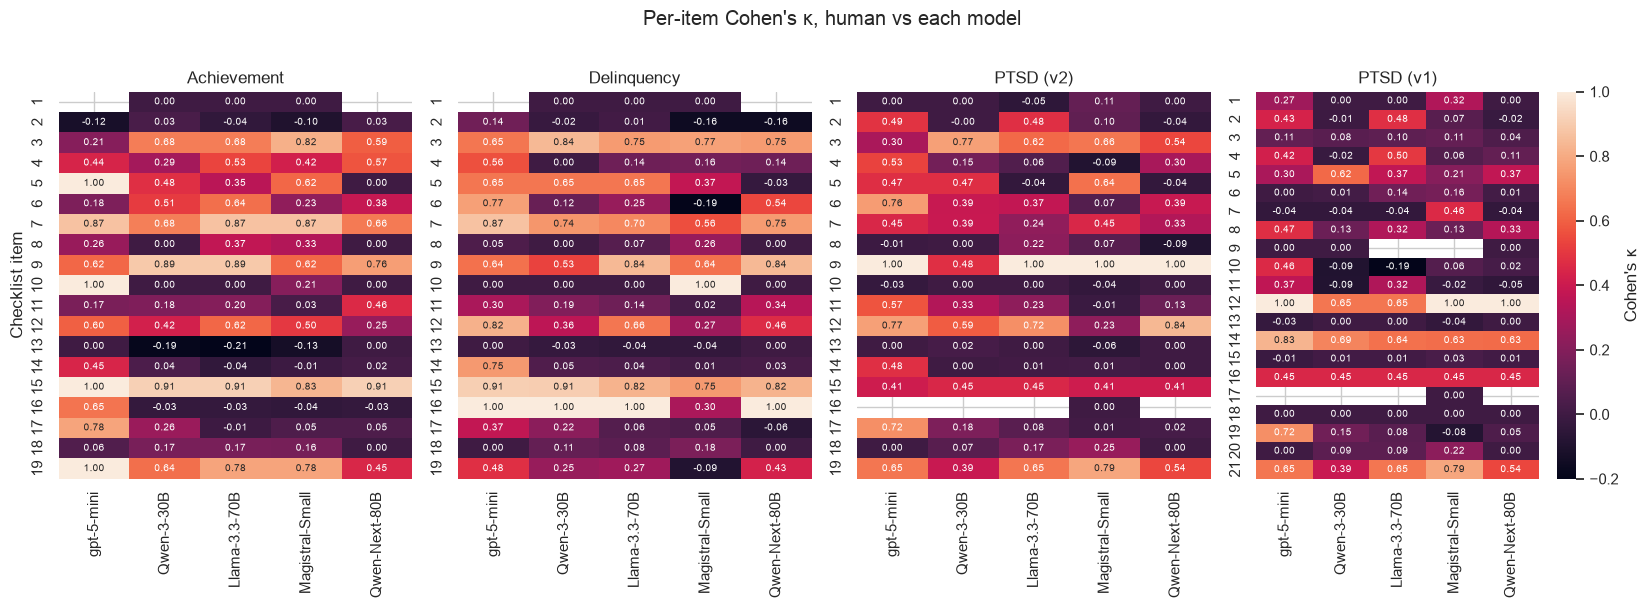

In [3]:
fig, axes = plt.subplots(1, len(tables), figsize=(4.2 * len(tables), 6), sharey=False)
for ax, (name, _) in zip(axes, CASES.items()):
    grid = (
        per_item[per_item["dataset"] == name]
        .pivot(index="item", columns="model", values="kappa")[LABELS]
    )
    sns.heatmap(grid, ax=ax, vmin=-0.2, vmax=1, cmap="rocket", annot=True, fmt=".2f",
                annot_kws={"size": 7}, cbar=(ax is axes[-1]),
                cbar_kws={"label": "Cohen's κ"} if ax is axes[-1] else None)
    ax.set_title(name)
    ax.set_xlabel("")
    ax.set_ylabel("Checklist item" if ax is axes[0] else "")
plt.suptitle("Per-item Cohen's κ, human vs each model", y=1.01)
plt.tight_layout()
VIZ.mkdir(parents=True, exist_ok=True)
plt.savefig(VIZ / "per_item_kappa.pdf", bbox_inches="tight")
plt.show()

In [4]:
# Items where the models agree with each other but not with the human: the confound R1 names.
agreement = pd.DataFrame({
    "human + 5 LLMs (Fleiss)": {n: ge.compute_fleiss_kappa(t.dropna()) for n, t in tables.items()},
    "5 LLMs only (Fleiss)": {n: ge.compute_fleiss_kappa(t.dropna(), LABELS) for n, t in tables.items()},
    "mean pairwise LLM–LLM (Cohen)": {n: ge.mean_pairwise_llm_kappa(t) for n, t in tables.items()},
    "mean human–LLM (Cohen)": {
        n: float(np.mean(list(ge.cohen_kappa_vs_human(t).values()))) for n, t in tables.items()
    },
})
agreement["model consensus − human agreement"] = (
    agreement["mean pairwise LLM–LLM (Cohen)"] - agreement["mean human–LLM (Cohen)"]
)
display(agreement.round(3))

,human + 5 LLMs (Fleiss),5 LLMs only (Fleiss),mean pairwise LLM–LLM (Cohen),mean human–LLM (Cohen),model consensus − human agreement
Achievement,0.596,0.610,0.612,0.569,0.043
Delinquency,0.617,0.652,0.652,0.550,0.102
PTSD (v2),0.596,0.655,0.655,0.476,0.179
PTSD (v1),0.500,0.563,0.567,0.393,0.173


## B2 · Confusion matrices and prevalence-robust metrics — *reviewer 1, minor 2*

Raw accuracy and κ are hard to read on items where the human answered "yes" to 3% or 97% of
studies. Full per-item counts are written to CSV for the appendix; the summary below is the part
that matters for the argument — **which direction the errors go**.

In [5]:
confusion = pd.concat(
    [ge.confusion_metrics(t).assign(dataset=name) for name, t in tables.items()],
    ignore_index=True,
)
confusion["item"] = confusion["question_id"] + 1
out = ge.EVAL_DIR / "tables" / f"confusion_by_item_chunk{CHUNK}.csv"
out.parent.mkdir(exist_ok=True)
confusion.drop(columns="question_id").to_csv(out, index=False)
print("per-item confusion matrices ->", out)

overall = pd.concat(
    [ge.confusion_metrics(t, by_item=False).assign(dataset=name) for name, t in tables.items()],
    ignore_index=True,
)
display(
    overall.groupby("dataset")[
        ["sensitivity", "specificity", "accuracy", "balanced_accuracy", "MCC", "PABAK"]
    ].mean().round(3)
)

per-item confusion matrices -> /Users/Kuil0004/Documents/repos/grolts-llm/eval/tables/confusion_by_item_chunk1000.csv


,sensitivity,specificity,accuracy,balanced_accuracy,MCC,PABAK
dataset,,,,,,
Achievement,0.891,0.670,0.789,0.780,0.582,0.577
Delinquency,0.869,0.671,0.783,0.770,0.557,0.566
PTSD (v1),0.881,0.528,0.687,0.705,0.432,0.374
PTSD (v2),0.879,0.596,0.739,0.737,0.497,0.478


In [6]:
# Error direction: the manuscript claims the models over-report ("YES on partial reporting").
direction = confusion.groupby("dataset")[["FP", "FN"]].sum()
direction["FP / (FP+FN)"] = direction["FP"] / (direction["FP"] + direction["FN"])
display(direction)

worst = (
    confusion.groupby(["dataset", "item"])
    .agg(FP=("FP", "sum"), FN=("FN", "sum"), human_prevalence=("human_prevalence", "mean"))
    .assign(net=lambda d: d["FP"] - d["FN"])
    .sort_values("net", ascending=False)
    .head(10)
)
print("\nItems the models most over-report (FP − FN, summed over models):")
display(worst)

,FP,FN,FP / (FP+FN)
dataset,,,
Achievement,464,178,0.722741
Delinquency,501,260,0.658344
PTSD (v1),1031,212,0.829445
PTSD (v2),716,221,0.764141



Items the models most over-report (FP − FN, summed over models):


FP  FN  human_prevalence  net
dataset     item                                
PTSD (v1)   18    169   0          0.000000  169
PTSD (v2)   13    155   1          0.160602  154
PTSD (v1)   15    149   1          0.158748  148
PTSD (v2)   14    128   2          0.159649  126
PTSD (v1)   6     126   2          0.184211  124
Delinquency 14    111   1          0.185736  110
            18    110   1          0.324324  109
PTSD (v1)   3      96   0          0.052916   96
Achievement 14     93   5          0.208333   88
PTSD (v1)   19     87   6          0.131579   81

## B3 · Matched-item v1 vs v2 comparison — *reviewer 1 major 4, reviewer 2 major 3*

Average agreement rose from v1 to v2, but four low-agreement v1 items were **removed** in v2, so
part of that rise is arithmetic rather than improvement. Restricting to the 17 v1 items that
survive into v2 separates the two.

*Note: this still compares against human labels collected under v1. Replace with the native v2
ratings from task A1 when they exist — that is the only version of this comparison that fully
answers the reviewers.*

In [7]:
v1 = tables["PTSD (v1)"]
matched_v1_items = sorted(ge.INVERSE_ID_MAP)          # 17 v1 items with a v2 counterpart
dropped_v1_items = sorted(ge.V1_ONLY_ITEMS)           # 4 v1 items removed in v2

acc_v1 = ge.item_accuracy_from_raters(v1).set_index("question_id")
acc_v2 = ge.item_accuracy_from_raters(tables["PTSD (v2)"]).set_index("question_id")

comparison = pd.DataFrame({
    "v1, all 21 items": acc_v1[LABELS].mean(),
    "v1, 17 matched items": acc_v1.loc[matched_v1_items, LABELS].mean(),
    "v1, 4 removed items": acc_v1.loc[dropped_v1_items, LABELS].mean(),
    "v2, all 19 items": acc_v2[LABELS].mean(),
}).T
comparison["mean"] = comparison.mean(axis=1)
display(comparison.round(3))

gain_total = comparison.loc["v2, all 19 items", "mean"] - comparison.loc["v1, all 21 items", "mean"]
gain_matched = comparison.loc["v2, all 19 items", "mean"] - comparison.loc["v1, 17 matched items", "mean"]
print(f"\nApparent gain, all items:      {gain_total:+.3f}")
print(f"Gain against matched items:    {gain_matched:+.3f}")
print(f"Attributable to item removal:  {gain_total - gain_matched:+.3f}")

,gpt-5-mini,Qwen-3-30B,Llama-3.3-70B,Magistral-Small,Qwen-Next-80B,mean
"v1, all 21 items",0.754,0.645,0.704,0.677,0.654,0.687
"v1, 17 matched items",0.782,0.701,0.735,0.714,0.711,0.729
"v1, 4 removed items",0.638,0.405,0.571,0.520,0.408,0.508
"v2, all 19 items",0.821,0.722,0.740,0.693,0.715,0.738



Apparent gain, all items:      +0.051
Gain against matched items:    +0.009
Attributable to item removal:  +0.042


In [8]:
# Item by item, for the appendix: what happened to each v1 item under the revision?
rows = []
for v1_item in sorted(set(matched_v1_items) | set(dropped_v1_items)):
    v2_items = ge.INVERSE_ID_MAP.get(v1_item, [])
    rows.append({
        "v1 item": v1_item + 1,
        "v1 agreement": acc_v1.loc[v1_item, LABELS].mean(),
        "fate": "removed" if not v2_items else ("split" if len(v2_items) > 1 else "kept"),
        "v2 item(s)": ", ".join(str(i + 1) for i in v2_items) or "—",
        "v2 agreement": acc_v2.loc[v2_items, LABELS].to_numpy().mean() if v2_items else np.nan,
    })
provenance = pd.DataFrame(rows).sort_values("v1 agreement")
display(provenance.round(3))

,v1 item,v1 agreement,fate,v2 item(s),v2 agreement
17,18,0.111,removed,—,NaN
14,15,0.207,split,"13, 14",0.236
5,6,0.326,kept,4,0.795
9,10,0.489,kept,7,0.672
2,3,0.492,removed,—,NaN
18,19,0.511,kept,17,0.521
3,4,0.625,removed,—,NaN
19,20,0.656,kept,18,0.662
10,11,0.684,kept,8,0.721
1,2,0.723,kept,2,0.698


## B4 · Non-circular tercile analysis — *reviewer 1, major 6*

Reviewer 1's objection is exact: items are labelled "high agreement" *because* the human and model
responses match, and then those same responses are summed and rank-correlated. The spread across
terciles is partly built in.

Two out-of-sample versions below. Datasets sharing a checklist version share item ids, so a tercile
assignment learned on one dataset can be applied to another.

In [9]:
transfer = ge.tercile_transfer({k: tables[k] for k in V2_CASES})
pivot = (
    transfer.groupby(["terciles from", "evaluated on", "in sample", "tercile"])["rho"]
    .mean().unstack("tercile")[["high", "mid", "low"]]
)
display(pivot.round(3))

print("\nIn-sample vs out-of-sample, averaged over models and datasets:")
display(
    transfer.groupby(["in sample", "tercile"])["rho"].mean()
    .unstack("tercile")[["high", "mid", "low"]].round(3)
)

tercile                                high    mid    low
terciles from evaluated on in sample                     
Achievement   Achievement  True       0.754  0.480  0.090
              Delinquency  False      0.713  0.587  0.242
              PTSD (v2)    False      0.606  0.484  0.382
Delinquency   Achievement  False      0.741  0.514  0.090
              Delinquency  True       0.798  0.580  0.242
              PTSD (v2)    False      0.310  0.511  0.382
PTSD (v2)     Achievement  False      0.439  0.637  0.105
              Delinquency  False      0.584  0.419  0.426
              PTSD (v2)    True       0.616  0.365  0.238


In-sample vs out-of-sample, averaged over models and datasets:


tercile,high,mid,low
in sample,,,
False,0.565,0.526,0.271
True,0.723,0.475,0.190


In [10]:
import warnings
from scipy.stats import ConstantInputWarning

# A half-sample can leave one tercile's totals constant for a model; rho is undefined there.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConstantInputWarning)
    split_half = pd.concat(
        [ge.split_half_tercile(tables[name], n_repeats=200).assign(dataset=name)
         for name in CASES],
        ignore_index=True,
    )
display(
    split_half.pivot_table(index="dataset", columns="tercile", values="mean")
    [["high", "mid", "low"]].round(3)
)
print(
    "Terciles assigned on a random half of the studies, rank correlations evaluated on the other\n"
    "half, averaged over 200 splits. Compare with the in-sample table in results_figures.ipynb:\n"
    "the high–low gap narrows but does not vanish, so the pattern survives the circularity."
)

tercile,high,mid,low
dataset,,,
Achievement,0.713,0.525,0.082
Delinquency,0.675,0.567,0.160
PTSD (v1),0.619,0.449,0.137
PTSD (v2),0.572,0.359,0.238


Terciles assigned on a random half of the studies, rank correlations evaluated on the other
half, averaged over 200 splits. Compare with the in-sample table in results_figures.ipynb:
the high–low gap narrows but does not vanish, so the pattern survives the circularity.


## B5 · Is the total score one dimension? — *reviewer 1, major 6*

The manuscript sums binary items into a "reporting quality" score without saying what licenses
treating them as one scale.

In [11]:
# The human labels are per dataset, not per checklist version: PTSD is rated on v1 only, so
# it appears once here rather than as both "PTSD (v1)" and "PTSD (v2)".
rows, item_totals = [], {}
for dataset in ge.DATASETS:
    labels_df = ge.load_human_labels(dataset)
    kr20, per_item_stats = ge.scale_diagnostics(labels_df)
    name = "PTSD (v1)" if dataset == "ptsd" else f"{dataset.capitalize()} (v2)"
    rows.append({"dataset": name, "items": labels_df["question_id"].nunique(), "KR-20": kr20})
    item_totals[name] = per_item_stats

display(pd.DataFrame(rows).round(3))
print(
    "KR-20 on the human labels. Values well below the conventional 0.70 would mean the items do\n"
    "not measure one thing, and the total is better described as a count of items reported —\n"
    "a completeness index — than as a latent quality score."
)

,dataset,items,KR-20
0,Achievement (v2),19,0.389
1,Delinquency (v2),19,0.451
2,PTSD (v1),21,0.409


KR-20 on the human labels. Values well below the conventional 0.70 would mean the items do
not measure one thing, and the total is better described as a count of items reported —
a completeness index — than as a latent quality score.


In [12]:
low_discrimination = pd.concat(
    [df.assign(dataset=name) for name, df in item_totals.items()], ignore_index=True
)
low_discrimination["item"] = low_discrimination["question_id"] + 1
print("Items correlating least with the rest of the checklist (corrected item–total r):")
display(
    low_discrimination.sort_values("item_total_r")
    [["dataset", "item", "prevalence", "item_total_r"]].head(12).round(3)
)

Items correlating least with the rest of the checklist (corrected item–total r):


,dataset,item,prevalence,item_total_r
43,PTSD (v1),6,0.184,-0.535
15,Achievement (v2),16,0.969,-0.241
27,Delinquency (v2),9,0.108,-0.198
16,Achievement (v2),17,0.094,-0.126
38,PTSD (v1),1,0.737,-0.119
4,Achievement (v2),5,0.906,-0.109
36,Delinquency (v2),18,0.324,-0.065
2,Achievement (v2),3,0.781,-0.036
10,Achievement (v2),11,0.781,-0.036
35,Delinquency (v2),17,0.108,-0.026


## B7 · Retrieval sensitivity: chunk 500 vs 1000 — *reviewer 2, major 2 (partial)*

Every headline number was also computed at a chunk size of 500 and never reported. This does not
address decoding stochasticity — that needs the sampled reruns in task A2 — but it does show the
conclusions are not an artefact of one retrieval configuration.

In [13]:
rows = []
for chunk in (500, 1000):
    for name, (dataset, qset) in CASES.items():
        t = rater_table(dataset, qset, chunk=chunk)
        rows.append({
            "chunk": chunk,
            "dataset": name,
            "Fleiss κ": ge.compute_fleiss_kappa(t.dropna()),
            "mean Cohen κ": float(np.mean(list(ge.cohen_kappa_vs_human(t).values()))),
            "mean ρ": float(np.mean(list(ge.spearman_vs_human(t).values()))),
        })
sensitivity = pd.DataFrame(rows).pivot(index="dataset", columns="chunk")
display(sensitivity.round(3))

Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-30B-A3B-Instruct-2507_achievement_500_4.csv: dropping 1/608 unparsed answers


rater table: 1/608 rows lack a model answer


Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-30B-A3B-Instruct-2507_delinquency_500_4.csv: dropping 1/703 unparsed answers


Qwen_Qwen3-Embedding-8B_mistralai_Magistral-Small-2509_delinquency_500_4.csv: dropping 1/703 unparsed answers


rater table: 2/703 rows lack a model answer


...

Qwen_Qwen3-Embedding-8B_meta-llama_Llama-3.3-70B-Instruct_ptsd_1000_0.csv: dropping 1/798 unparsed answers


Qwen_Qwen3-Embedding-8B_mistralai_Magistral-Small-2509_ptsd_1000_0.csv: dropping 7/798 unparsed answers


Qwen_Qwen3-Embedding-8B_Qwen_Qwen3-Next-80B-A3B-Instruct_ptsd_1000_0.csv: dropping 1/798 unparsed answers


rater table: 14/798 rows lack a model answer


Fleiss κ        mean Cohen κ        mean ρ       
chunk           500    1000         500    1000   500    1000
dataset                                                      
Achievement    0.603  0.596        0.522  0.569  0.539  0.484
Delinquency    0.642  0.617        0.559  0.550  0.485  0.526
PTSD (v1)      0.539  0.500        0.411  0.393  0.514  0.513
PTSD (v2)      0.599  0.596        0.500  0.476  0.452  0.492

## B6 · What did the disagreement analysis actually contribute? — *reviewer 1, major 1*

The four revision principles are ordinary checklist-design principles, and eight experts reviewed
the result, so reviewer 1 asks what the model disagreement added. The answer available here is that
the stored model **reasoning** shows the mechanism behind each low-agreement item — which item to
revise, and why.

The counts below are keyword heuristics over the reasoning text. They locate candidate cases; the
classification still needs a human pass (task B6 in `REVISION.md`) before it goes in the paper.

In [14]:
def reasoning_for(dataset, qset, chunk=CHUNK):
    frames = []
    for label, file in zip(LABELS, ge.output_files(dataset, chunk=chunk, qset=qset)):
        df = pd.read_csv(file)[["paper_id", "question_id", "reasoning", "answer"]]
        frames.append(df.assign(model=label))
    out = pd.concat(frames, ignore_index=True).dropna(subset=["answer"])
    human = ge.load_human_labels(dataset).rename(columns={"answer": "human"})
    return out.merge(human, on=["paper_id", "question_id"])


v1_reasoning = reasoning_for("ptsd", ge.QSET_V1)

# Items 15 and 18 both require the criterion to hold for *every model tested*. The failure mode
# is not that the model says "final model" — it is that it never engages with the "all models"
# condition at all, judging the criterion satisfied from whichever solution the paper describes.
ALL_MODELS = re.compile(r"each model|all models|every model|all of the models|all tested"
                        r"|all fitted|each of the models|across models", re.I)
ONE_SOLUTION = re.compile(r"final model|selected|best[- ]fitting|chosen|preferred"
                          r"|\b(?:two|three|four|five|six)[- ]class|\b\d+[- ]class", re.I)
# Item 6 asks about the distribution of observed variables, not about descriptive statistics.
DESCRIPTIVE = re.compile(r"\bmeans?\b|standard deviation|\bSDs?\b|descriptive|\brange\b"
                         r"|percentage|median", re.I)
DISTRIBUTIONAL = re.compile(r"normality|normally distributed|skew|kurtosis|multivariate normal"
                            r"|Shapiro|Kolmogorov|distributional", re.I)

PROBES = {
    "15 — cases per class, all models tested": (14, "all-models"),
    "18 — plots for each model": (17, "all-models"),
    "6 — distribution of observed variables": (5, "distribution"),
}

rows = []
for name, (qid, kind) in PROBES.items():
    item = v1_reasoning[v1_reasoning["question_id"] == qid]
    fp = item[(item["human"] == 0) & (item["answer"] == 1)]
    text = fp["reasoning"].fillna("")

    if kind == "all-models":
        flagged = ~text.str.contains(ALL_MODELS)
        mechanism = "never mentions all/each model"
        corroborating = float(text.str.contains(ONE_SOLUTION).mean()) if len(fp) else np.nan
        corroborating_label = "names one specific solution"
    else:
        flagged = text.str.contains(DESCRIPTIVE) & ~text.str.contains(DISTRIBUTIONAL)
        mechanism = "cites descriptives, no distributional test"
        corroborating = float(text.str.contains(DISTRIBUTIONAL).mean()) if len(fp) else np.nan
        corroborating_label = "mentions a distributional test"

    rows.append({
        "v1 item": name,
        "model answers": len(item),
        "false positives": len(fp),
        "FP rate": len(fp) / len(item) if len(item) else np.nan,
        "mechanism": mechanism,
        "share of FPs": float(flagged.mean()) if len(fp) else np.nan,
        "cross-check": corroborating_label,
        "share": corroborating,
    })

display(pd.DataFrame(rows).round(3))
print(
    "Keyword heuristics over the stored reasoning, not a validated classifier: they locate the\n"
    "candidate cases for the human pass (task B6). What they show is that when the models answer\n"
    "YES where the human said NO, the reasoning is almost never engaging with the condition the\n"
    "item actually sets — which is an argument for rewording the item, not for a better model."
)

,v1 item,model answers,false positives,FP rate,mechanism,share of FPs,cross-check,share
0,"15 — cases per class, all models tested",189,149,0.788,never mentions all/each model,0.658,names one specific solution,0.188
1,18 — plots for each model,190,169,0.889,never mentions all/each model,0.272,names one specific solution,0.225
2,6 — distribution of observed variables,190,126,0.663,"cites descriptives, no distributional test",0.619,mentions a distributional test,0.341


Keyword heuristics over the stored reasoning, not a validated classifier: they locate the
candidate cases for the human pass (task B6). What they show is that when the models answer
YES where the human said NO, the reasoning is almost never engaging with the condition the
item actually sets — which is an argument for rewording the item, not for a better model.


In [15]:
# Read a few of them: the qualitative evidence the appendix table needs.
item = v1_reasoning[v1_reasoning["question_id"] == 14]
fp = item[(item["human"] == 0) & (item["answer"] == 1)]
for _, row in fp.head(3).iterrows():
    print(f"[{row['model']}, paper {row['paper_id']}]")
    print(str(row["reasoning"])[:400].replace("\n", " "), "\n")

[gpt-5-mini, paper 7]
The CONTEXT explicitly lists the number of participants (n =) and the corresponding percentages for each trajectory class in the four-class solution, showing absolute sample sizes and proportions. 

[gpt-5-mini, paper 10]
The paper reports the proportion (percent) of participants in each trajectory/class for the selected solutions within each tertile, and also reports the total sample size for each tertile, but does not provide absolute counts for each class. Therefore the number of cases per class is reported as proportions. 

[gpt-5-mini, paper 3]
The CONTEXT explicitly reports class sizes both as proportions and as absolute counts. The four-trajectory solution lists percentages for each class and gives the delayed class's absolute n, and the three-class solution's Table 2 displays both the absolute sample sizes (n) and percentages (%) for each class. 



## A2 · Run-to-run stability — *reviewer 2, major 2; reviewer 2, minor 8*

The manuscript states that "repeated runs on a subset of document–question pairs confirmed stable
outputs". Those runs were done, but their outputs were not retained here, so this section rebuilds
the evidence from the rerun campaign.

Two asymmetries shape how it is read:

- **The local models change inference engine.** The published runs used transformers; the campaign
  uses vLLM. Each vLLM job therefore also produces a greedy pass, so greedy-vs-sampled isolates
  sampling noise and vLLM-greedy vs transformers-greedy is a separate engine check.
- **gpt-5-mini has no greedy run and never did** — the GPT-5 family rejects an explicit
  temperature, so the published result was already a single sampled draw. No new baseline is
  needed: same model, prompts and parameters give 5 fresh draws, and the published one is a 6th
  taken months earlier, which makes it a free test of temporal drift.

Until the runs land, the cells below report that nothing is on disk.

In [16]:
STABILITY_DATASET, STABILITY_QSET = "ptsd", ge.QSET_V2
vllm_runs = ge.available_runs(STABILITY_DATASET, chunk=CHUNK, qset=STABILITY_QSET, engine="vllm")
human = ge.load_human_labels(STABILITY_DATASET).rename(columns={"answer": "human"})
MAPPING = ge.INVERSE_ID_MAP if STABILITY_DATASET == "ptsd" else None


def kappa_for(long_frame):
    """Cohen's kappa vs the human labels, from a long frame of answers."""
    wide = long_frame.pivot(
        index=["paper_id", "question_id"], columns="model", values="answer"
    ).reset_index()
    return ge.cohen_kappa_vs_human(human.merge(wide, on=["paper_id", "question_id"]))


if not vllm_runs:
    print(
        f"No vLLM reruns on disk for {STABILITY_DATASET} (chunk {CHUNK}, qset {STABILITY_QSET}).\n"
        "Task A2 in REVISION.md has the commands; this section fills in once they have run."
    )
else:
    df_runs = ge.load_runs(
        STABILITY_DATASET, vllm_runs, chunk=CHUNK, qset=STABILITY_QSET, engine="vllm"
    )
    print(f"{len(vllm_runs)} sampled runs x {df_runs['model'].nunique()} models")
    display(ge.response_stability(df_runs).round(3))

    per_run = {
        f"run {r}": pd.Series(kappa_for(
            ge.load_runs(STABILITY_DATASET, [r], chunk=CHUNK, qset=STABILITY_QSET, engine="vllm")
        ))
        for r in vllm_runs
    }
    comparison = pd.DataFrame(per_run)
    comparison["spread"] = comparison.max(axis=1) - comparison.min(axis=1)
    comparison["majority vote"] = pd.Series(kappa_for(
        ge.majority_vote(df_runs).melt(
            id_vars=["paper_id", "question_id"], var_name="model", value_name="answer"
        )
    ))
    display(comparison.round(3))
    print(
        "The spread across runs is the honest uncertainty band on every kappa in the paper.\n"
        "Report the majority-vote column as the headline and the spread beside it."
    )

No vLLM reruns on disk for ptsd (chunk 1000, qset 4).
Task A2 in REVISION.md has the commands; this section fills in once they have run.


### Does the published gpt-5-mini run still sit inside the new spread?

The published gpt-5-mini result is a 6th draw from the same distribution, taken months earlier. If
it falls inside the envelope of the five new runs, that is direct evidence the published numbers
remain representative despite the elapsed time. If it is an outlier, something on the serving side
changed and the published figure needs more caution — worth knowing before defending it.

This works only for gpt-5-mini. The local models' published runs used a different engine, so their
equivalent check is the engine comparison below.

In [17]:
MODEL = "gpt-5-mini"
# Only gpt-5-mini writes untagged _run{i} files; the local models are tagged _vllm.
openai_runs = ge.available_runs(
    STABILITY_DATASET, chunk=CHUNK, qset=STABILITY_QSET, models=[MODEL]
)
if not openai_runs:
    print("No gpt-5-mini reruns on disk yet.")
else:
    fresh = [
        kappa_for(
            ge.load_runs(
                STABILITY_DATASET, [r], chunk=CHUNK, qset=STABILITY_QSET, labels=[MODEL]
            )
        )[MODEL]
        for r in openai_runs
    ]
    published = ge.cohen_kappa_vs_human(
        ge.build_rater_table(
            ge.load_human_labels(STABILITY_DATASET),
            ge.output_files(STABILITY_DATASET, chunk=CHUNK, qset=STABILITY_QSET),
            MAPPING,
        )
    )[MODEL]
    low, high = min(fresh), max(fresh)
    inside = low <= published <= high
    print(f"gpt-5-mini kappa, {len(fresh)} new runs : {low:.3f} to {high:.3f}")
    print(f"published run (months earlier)      : {published:.3f}")
    print(
        f"-> {'inside' if inside else 'OUTSIDE'} the new envelope"
        + ("" if inside else "   <-- investigate before relying on the published figure")
    )

No gpt-5-mini reruns on disk yet.


### Engine sensitivity: vLLM greedy vs transformers greedy

For the four local models only. Same prompts, same weights, same greedy decoding — any difference
is the inference engine. Small differences are expected; large ones would mean the published
numbers are engine-specific and must be reported as such.

In [18]:
greedy_vllm = ge.output_files(STABILITY_DATASET, chunk=CHUNK, qset=STABILITY_QSET, engine="vllm")

if not all(f.exists() for f in greedy_vllm):
    print("No vLLM greedy pass on disk yet (produced by --also-greedy).")
else:
    labels = ge.load_human_labels(STABILITY_DATASET)
    engines = pd.DataFrame({
        "transformers (published)": ge.cohen_kappa_vs_human(
            ge.build_rater_table(
                labels,
                ge.output_files(STABILITY_DATASET, chunk=CHUNK, qset=STABILITY_QSET),
                MAPPING,
            )
        ),
        "vLLM greedy": ge.cohen_kappa_vs_human(ge.build_rater_table(labels, greedy_vllm, MAPPING)),
    })
    engines["difference"] = engines["vLLM greedy"] - engines["transformers (published)"]
    # gpt-5-mini never had a greedy run, so it is not part of this comparison.
    display(engines.drop(index="gpt-5-mini", errors="ignore").round(3))

No vLLM greedy pass on disk yet (produced by --also-greedy).


### Does sampling rescue the degenerate responses?

47 cells in the published runs have no parseable answer — not random dropout, but Magistral and
Qwen-3-30B looping on markdown table pipes while quoting evidence until the 1500-token budget runs
out, so the ANSWER section is never reached.

Greedy decoding always takes the argmax, so the vLLM greedy pass should walk into the same loops.
Sampling at temperature 0.7 should break most of them, and a majority vote over five runs should
recover nearly all. That is a prediction; this cell measures it.

If it holds, it is a reportable practical benefit of the sampled runs rather than something that
had to be engineered — and it is why the parse-failure rate belongs in Methods alongside the
pairwise-deletion rule.

In [19]:
published = ge.unparsed_counts(ge.output_files(STABILITY_DATASET, chunk=CHUNK, qset=STABILITY_QSET))
LOCAL = [m for m in LABELS if m != "gpt-5-mini"]
table = {"published (transformers greedy)": published}

greedy_files = ge.output_files(STABILITY_DATASET, chunk=CHUNK, qset=STABILITY_QSET, engine="vllm")
if all(f.exists() for f in greedy_files):
    table["vLLM greedy"] = ge.unparsed_counts(greedy_files)

for r in vllm_runs:
    table[f"vLLM run {r}"] = ge.unparsed_counts(
        ge.output_files(
            STABILITY_DATASET, chunk=CHUNK, qset=STABILITY_QSET,
            engine="vllm", run=r, models=LOCAL,
        ),
        labels=LOCAL,
    )

failures = pd.DataFrame(table)
display(failures)

if vllm_runs:
    # A cell is only truly lost if no run answered it.
    answered = ge.load_runs(
        STABILITY_DATASET, vllm_runs, chunk=CHUNK, qset=STABILITY_QSET, engine="vllm"
    ).groupby(["model", "paper_id", "question_id"]).size()
    n_cells = (
        ge.load_human_labels(STABILITY_DATASET)["paper_id"].nunique()
        * ge.load_human_labels(STABILITY_DATASET)["question_id"].nunique()
    )
    lost = {m: n_cells - len(answered.loc[m]) for m in answered.index.get_level_values(0).unique()}
    print("\ncells with no answer in ANY of the sampled runs (majority vote is undefined there):")
    print(pd.Series(lost, name="lost").to_string())
else:
    print("\nAwaiting the reruns; only the published column is available.")

,published (transformers greedy)
gpt-5-mini,0
Qwen-3-30B,5
Llama-3.3-70B,0
Magistral-Small,11
Qwen-Next-80B,1



Awaiting the reruns; only the published column is available.
